# Two-State Benchmark

This notebook is the compact validation page for the finite-state toy benchmark. It keeps the main scientific figures first and moves estimator checks into a short appendix.

## Environment Basics

- State space: $\mathcal{X}=\{0,1\}$.
- Action space: $\mathcal{A}=\{0,1\}$.
- Population law: $\mu_t\in\Delta(\mathcal{X})$, with the key observable $\mu_t(1)$.
- Goal: learn a policy whose induced population trajectory tracks the target mass $p$ while matching the exact small-state oracle.
- Compared algorithms: simplex MF-REINFORCE, logit/CLR MF-REINFORCE, and classical REINFORCE.

A generic finite-state objective is

$$
J(\theta)=\mathbb{E}_{\pi_\theta}\left[\sum_{t=0}^{T-1} r(X_t,A_t,\mu_t)+g(X_T,\mu_T)\right].
$$

Here the main visible check is the exact target-tracking trajectory $\mu_t(1)$ and the learned action probabilities $\pi_\theta(a\mid x)$.


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "twostate"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "smoke"
RUN_MISSING = False
FORCE_REBUILD = False
EXTENDED = True


In [2]:
bundle = (
    nh.ensure_discrete_benchmark_bundle(
        ENV_NAME,
        BASE_DIR,
        quick=QUICK,
        force=FORCE_REBUILD,
        extended=EXTENDED,
        preset=PRESET,
    )
    if RUN_MISSING
    else nh.bundle_paths(ENV_NAME, BASE_DIR)
)

histories = nh.load_training_histories(bundle)
application = nh.load_application_data(bundle)
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
diagnostics = nh.load_diagnostic_data(bundle)
optimization_history = nh.load_optimization_history(bundle)

bundle


{'env': 'twostate',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate'),
 'train': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate/train/twostate_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate/train/twostate_logits'),
  'reinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate/train/twostate_reinforce')},
 'application': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate/application/twostate_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate/application/twostate_logits'),
  'reinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/twostate/application/twostate_reinforce')},
 'diagnostics': {'simplex': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_

## Main Results

These are the minimum figures to inspect first.

1. **Validation value over training**: $J(\theta_k)$ against the exact reference value.
2. **Population trajectory**: $\mu_t(1)$ compared with the target $p$ and exact optimal trajectory.
3. **Learned policy**: $\pi(a=1\mid x)$ compared with the exact optimal stationary policy.
4. **Objective landscape**: the exact two-parameter landscape $J(\theta_0,\theta_1)$ when available.


,algorithm,learned_value_J,reference_value_J_star,value_gap,final_mu_T_1,target_error,policy_l1_mean_error
0,MF-REINFORCE simplex,-4.172950,-1.92,2.252950,0.388249,0.011751,0.273498
1,MF-REINFORCE logits,-4.673376,-1.92,2.753376,0.375256,0.024744,0.280683
2,classical REINFORCE,-20.839500,-1.92,18.919500,0.617973,0.217973,0.295195


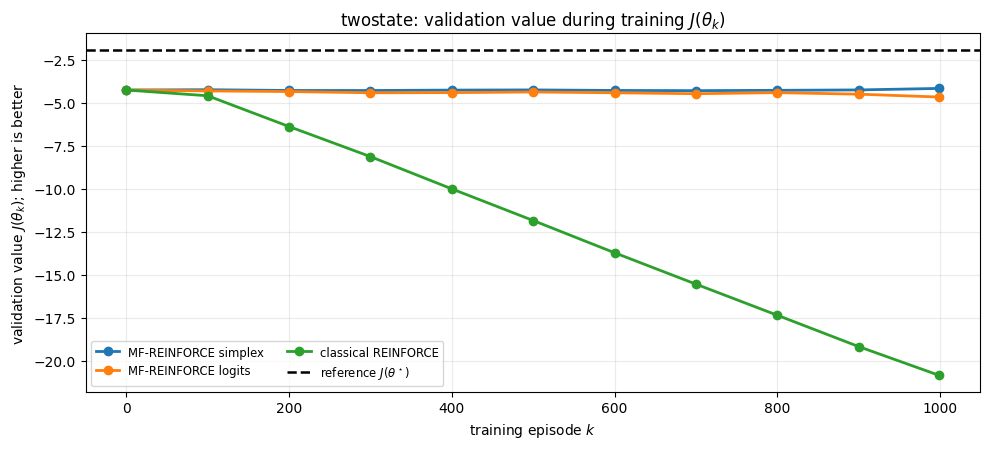

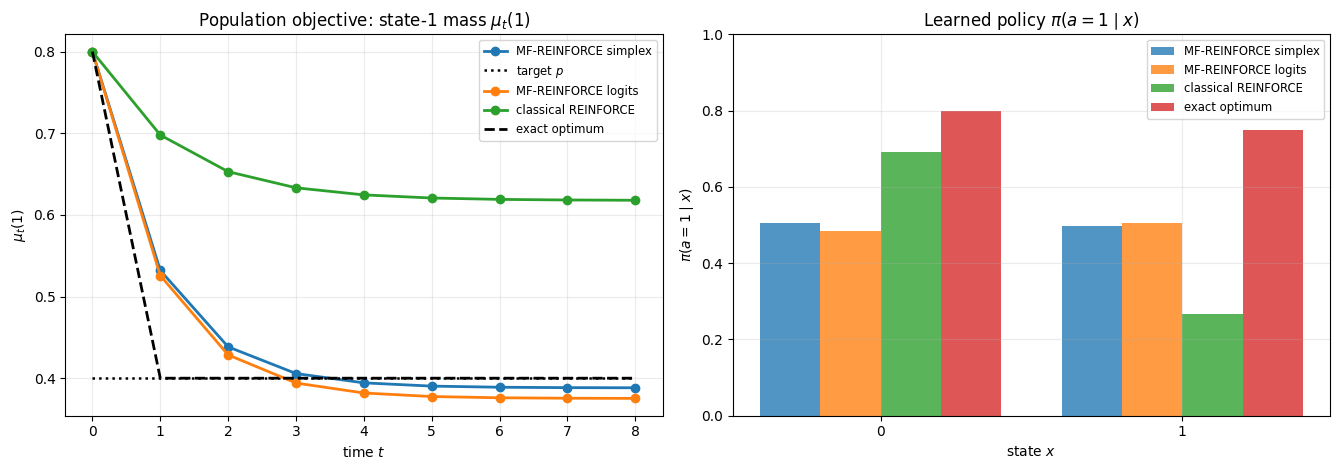

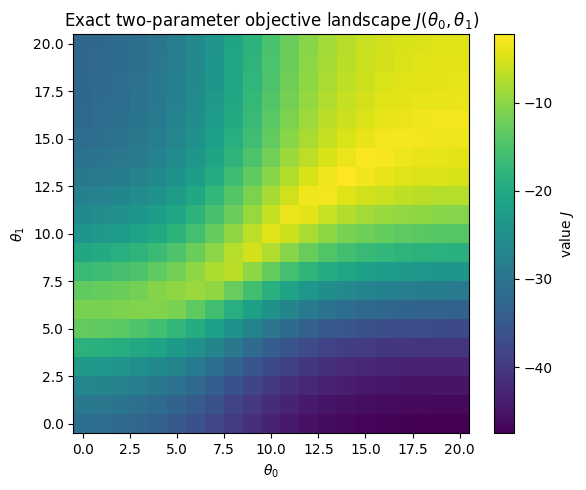

In [3]:
display(nh.discrete_main_summary_table(ENV_NAME, application))
nh.plot_discrete_main_results(ENV_NAME, histories, application)


## Estimator Diagnostic Appendix

These plots are supporting checks for the estimator chain. They are useful when a training curve looks suspicious, but they are not the first thing to interpret.

The panels summarize

$$
\mathbb{E}[d(M^\lambda,\mu)],
\qquad
\operatorname{MSE}(\widehat g)=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\operatorname{tr}\operatorname{Cov}(S_\lambda),
\qquad
\mathbb{E}\|\widehat D_t-D_t\|_2^2.
$$

Here $S_\lambda=\nabla_\theta\log q_\lambda(M)$ is the population-law score and $D_t=\partial\mu_t/\partial\theta$ is the population sensitivity.


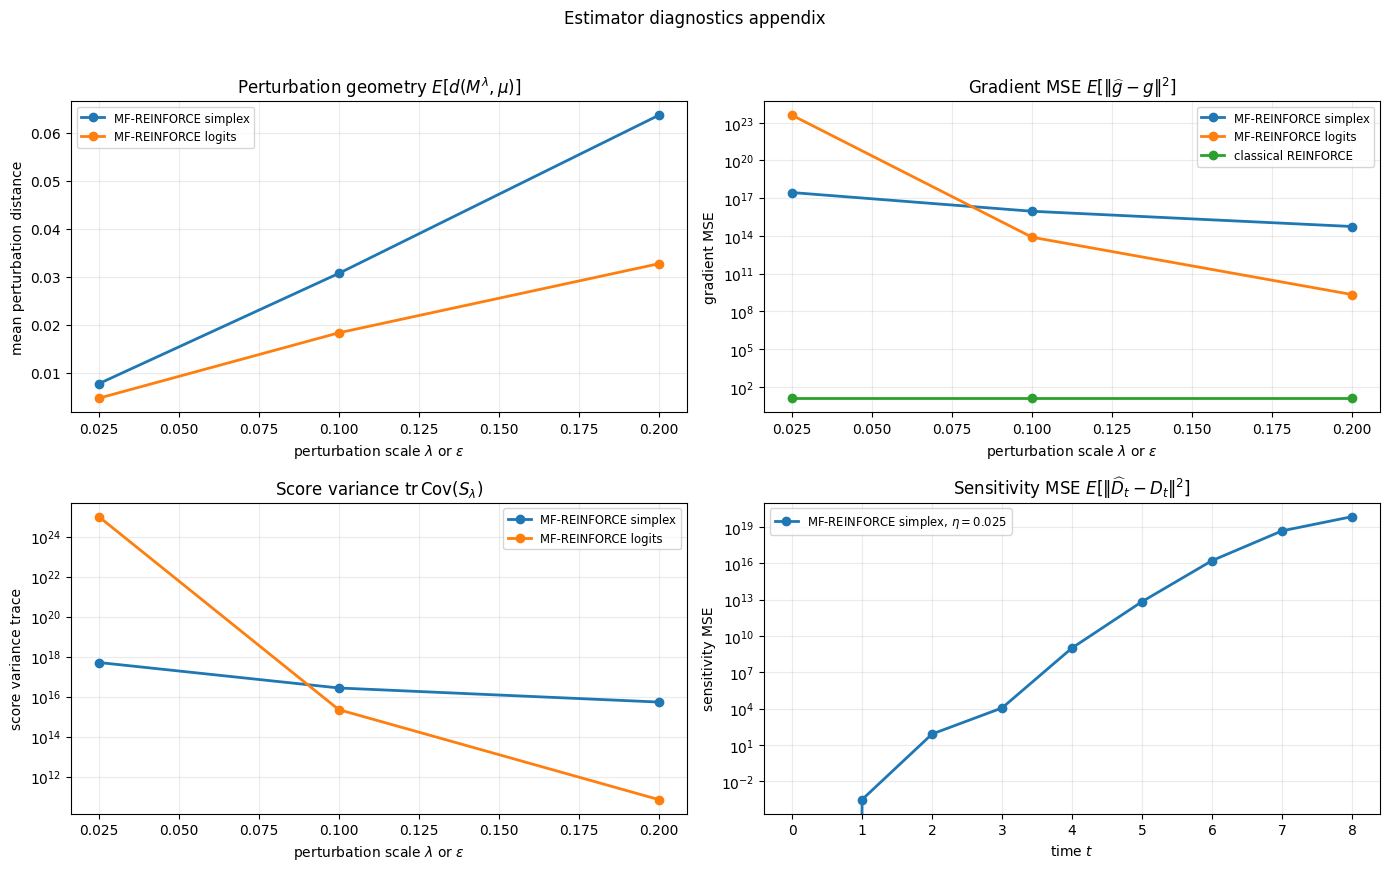

In [4]:
nh.plot_discrete_diagnostic_appendix(diagnostics)


## Total-Variation Calibration

For finite laws $p,q\in\Delta(\mathcal{X})$,

$$
d_{TV}(p,q)=\frac{1}{2}\|p-q\|_1.
$$

The simplex perturbation has a pathwise TV bound proportional to $\lambda$. The logit/CLR perturbation is checked against its reference radius. The table reports empirical expectations, quantiles, and violation rates.


,algorithm,parameter,value,samples,E_d_TV,median_d_TV,p90_d_TV,max_d_TV,comparison_kind,comparison_radius,pathwise_bound,violation_count,violation_rate,simplex_expected_unit_radius,simplex_min_slack,logit_reference_size,logit_mean_over_reference,logit_min_reference_slack
0,simplex,lambda,0.025,96,0.007716,0.006936,0.014005,0.018545,simplex pathwise bound lambda,0.0250,0.025,0,0.00000,0.308624,0.006455,NaN,NaN,NaN
1,logits,epsilon,0.025,96,0.004698,0.004355,0.009126,0.012158,logit reference epsilon/2,0.0125,NaN,0,0.00000,NaN,NaN,0.0125,0.375813,0.000342
2,simplex,lambda,0.100,96,0.030697,0.027933,0.056754,0.076049,simplex pathwise bound lambda,0.1000,0.100,0,0.00000,0.306974,0.023951,NaN,NaN,NaN
3,logits,epsilon,0.100,96,0.018317,0.015753,0.034941,0.073429,logit reference epsilon/2,0.0500,NaN,3,0.03125,NaN,NaN,0.0500,0.366330,-0.023429
4,simplex,lambda,0.200,96,0.063642,0.062330,0.115983,0.148440,simplex pathwise bound lambda,0.2000,0.200,0,0.00000,0.318209,0.051560,NaN,NaN,NaN
5,logits,epsilon,0.200,96,0.032711,0.030527,0.062297,0.123050,logit reference epsilon/2,0.1000,NaN,3,0.03125,NaN,NaN,0.1000,0.327114,-0.023050


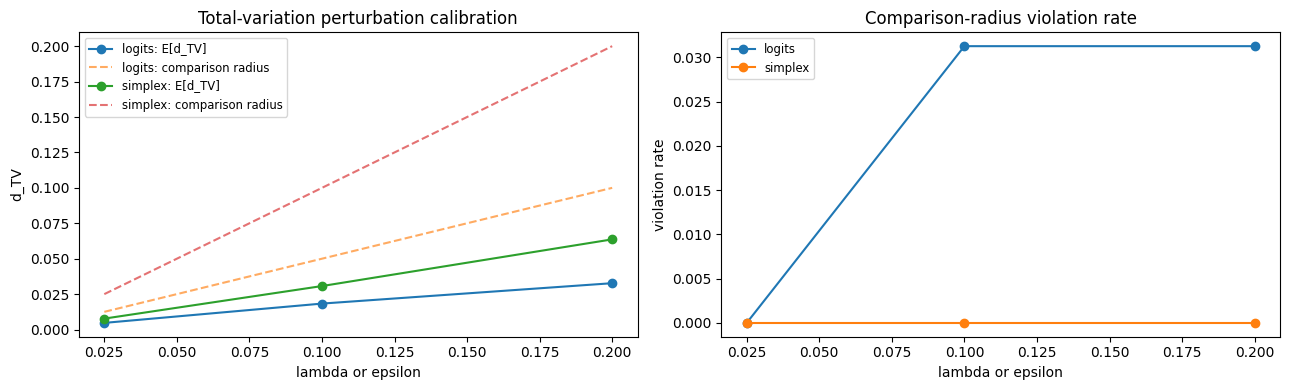

In [5]:
tv_table = nh.perturbation_tv_comparison_table(diagnostics)
display(tv_table)
nh.plot_perturbation_tv_comparison(diagnostics)


## Optional Extended Studies

Run this section when checking budget allocation, horizon scaling, adaptive lambda, ablations, or robustness. These plots are intentionally separated from the main benchmark result.


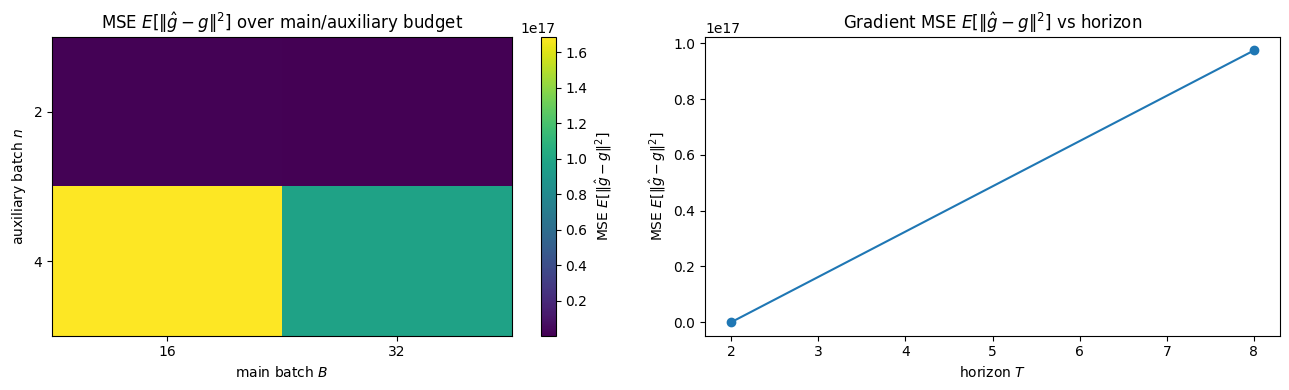

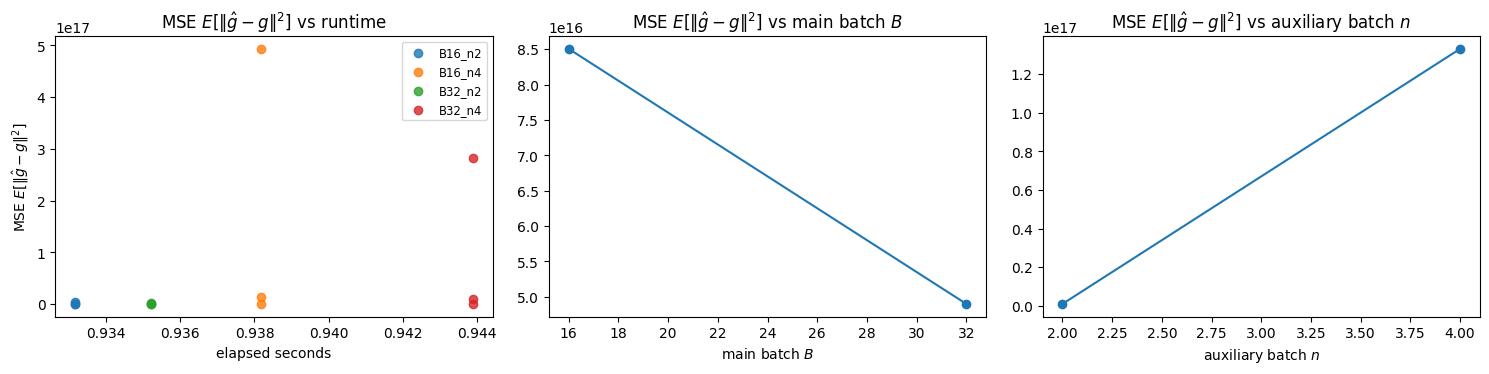

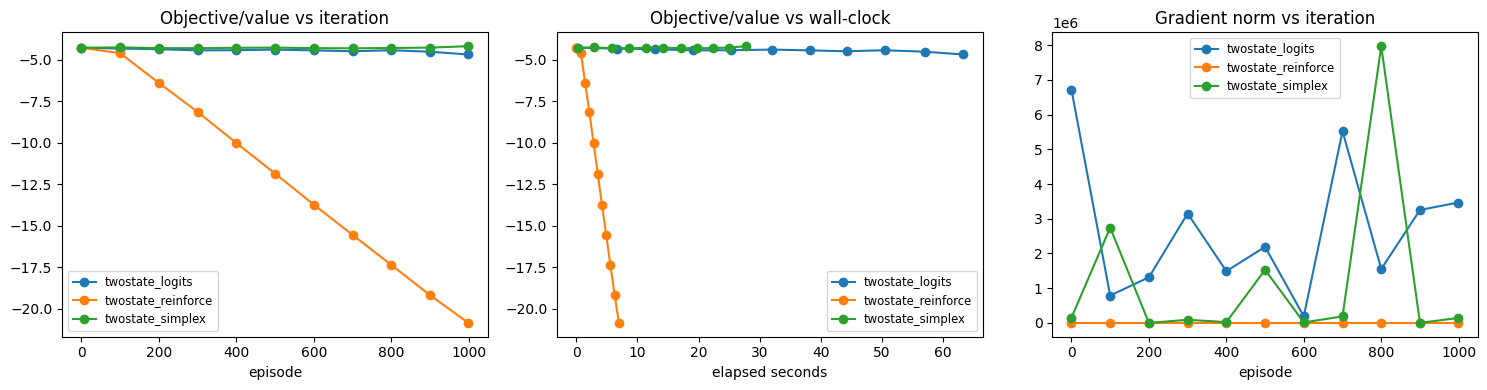

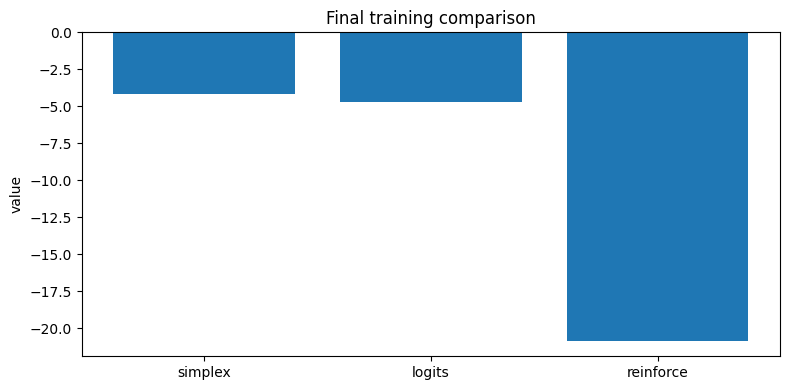

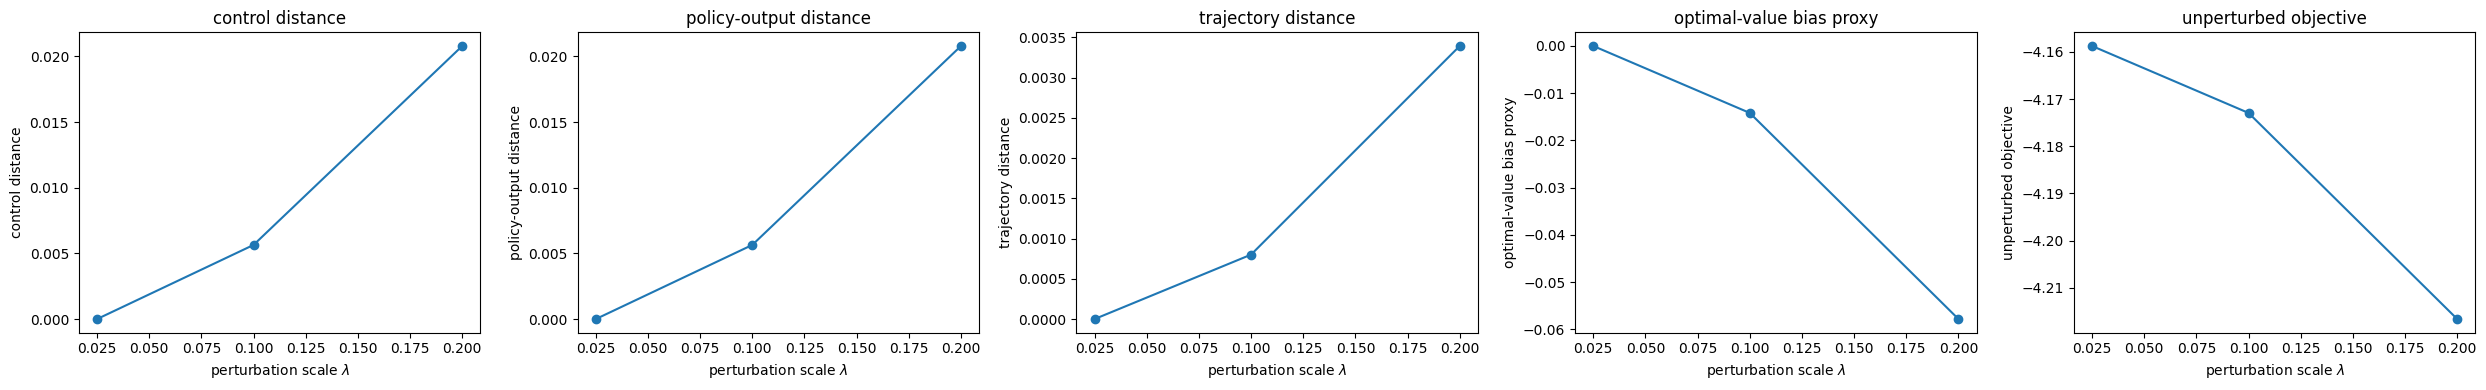

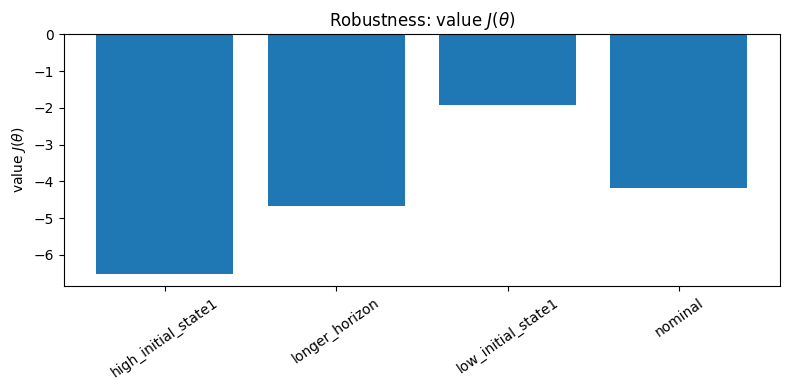

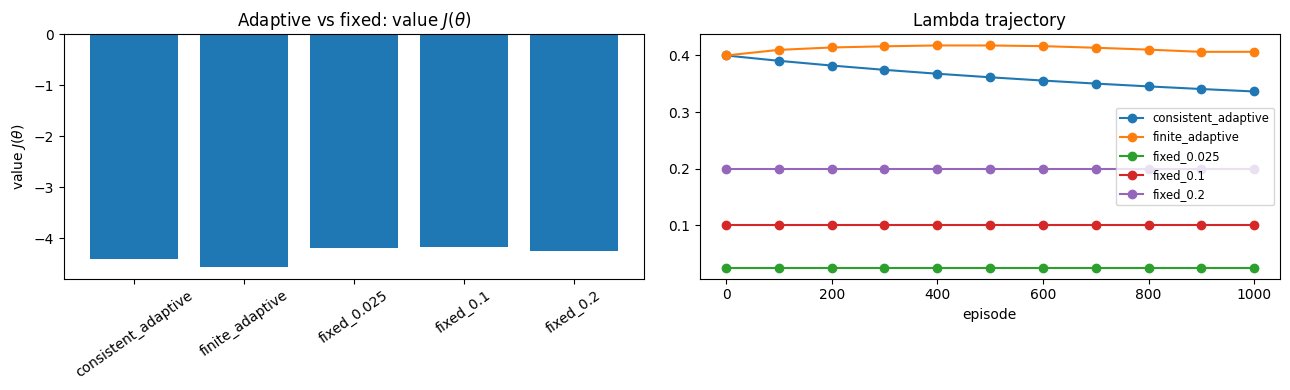

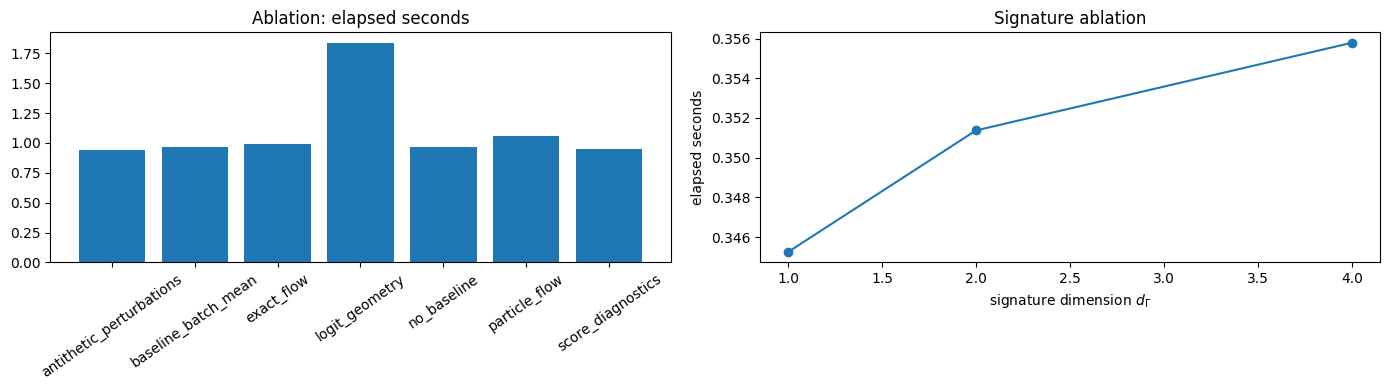

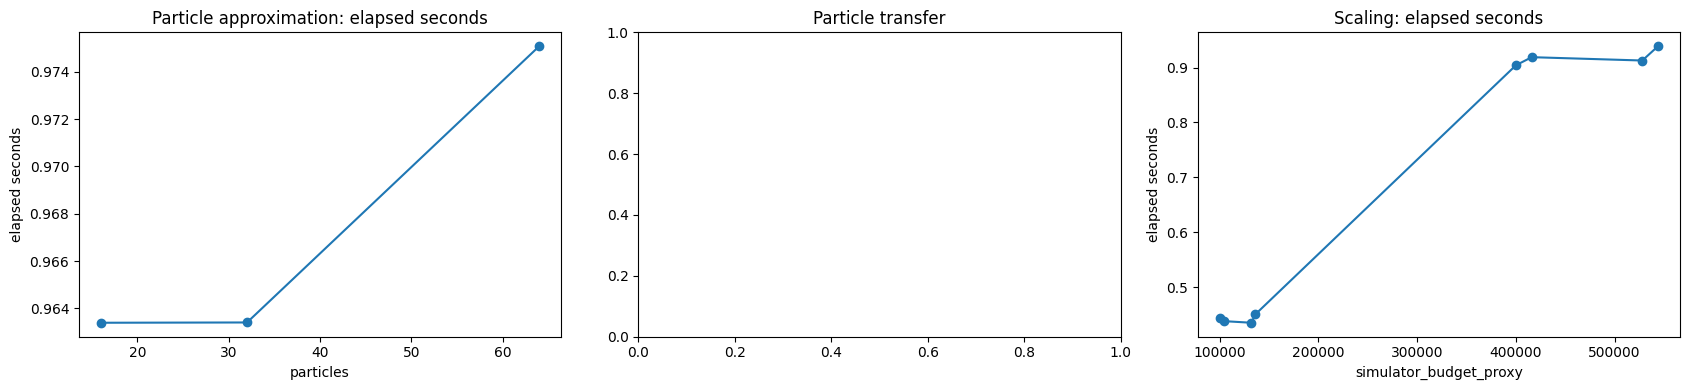

In [6]:
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_lambda_training_comparison(studies)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)
nh.plot_extended_study_summaries(studies, grid_metrics)


## Figure Coverage Audit

These tables map the broader requested figure list to saved artifacts. They are useful for checking completeness; they are not meant to be the headline story of the benchmark.


In [7]:
nh.figure_checklist(ENV_NAME)


,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [8]:
nh.figure_coverage_matrix(ENV_NAME)


,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Raw Tables For Custom Figures

The first few rows below are the main saved tables used by the plots above. Use these as the entry point for custom figures without rerunning training.


In [9]:
sample_algorithm = next(iter(application))
sample_diag_algorithm = next(iter(diagnostics))
(
    application[sample_algorithm]["time_metrics"].head(),
    diagnostics[sample_diag_algorithm].get("gradient", pd.DataFrame()).head(),
    studies.get("budget", pd.DataFrame()).head(),
)


(        env  law_index  time  mass_state_1  target_state_1  target_abs_error
 0  twostate          0     0      0.800000             0.4          0.400000
 1  twostate          0     1      0.531962             0.4          0.131962
 2  twostate          0     2      0.438370             0.4          0.038370
 3  twostate          0     3      0.405691             0.4          0.005691
 4  twostate          0     4      0.394280             0.4          0.005720,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8   1.870781e+08    2.830511e+17   
 1   0.100             8   3.412178e+07    9.178693e+15   
 2   0.200             8   8.691227e+06    5.580422e+14   
 
    covariance_largest_eigenvalue  oracle_norm     bias_norm  relative_bias  \
 0                   2.830249e+17     4.352752  1.870781e+08   4.297926e+07   
 1                   9.178227e+15     4.352752  3.412178e+07   7.839129e+06   
 2                   5.572903e+14     4.352752  8.691229